In [114]:
import pandas as pd

df = pd.read_csv('Bakery sales.csv')

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234005 entries, 0 to 234004
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Unnamed: 0     234005 non-null  int64  
 1   date           234005 non-null  object 
 2   time           234005 non-null  object 
 3   ticket_number  234005 non-null  float64
 4   article        234005 non-null  object 
 5   Quantity       234005 non-null  float64
 6   unit_price     234005 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 12.5+ MB


In [116]:
df.isnull().sum()

Unnamed: 0       0
date             0
time             0
ticket_number    0
article          0
Quantity         0
unit_price       0
dtype: int64

In [117]:
df.isna().sum()

Unnamed: 0       0
date             0
time             0
ticket_number    0
article          0
Quantity         0
unit_price       0
dtype: int64

In [118]:
from collections import Counter
all_products_buy = Counter(df['article'])

In [119]:
df = df.drop(['Unnamed: 0', 'ticket_number'], axis=1)
df['unit_price'] = df['unit_price'].str.replace(' €', '').str.replace(',', '.').astype(float)

In [120]:
df['hour'] = pd.to_datetime(df['time'], format='%H:%M').dt.hour

/tmp/ipykernel_1051231/3811547182.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hour_sales, x='hour', y='Quantity', palette='viridis')


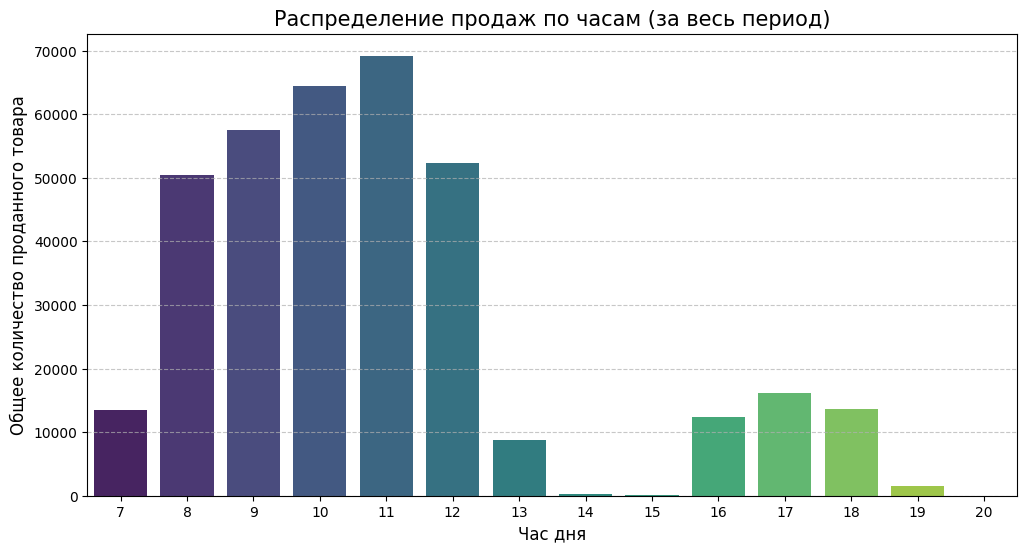

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

hour_sales = df.groupby('hour')['Quantity'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=hour_sales, x='hour', y='Quantity', palette='viridis')

plt.title('Распределение продаж по часам (за весь период)', fontsize=15)
plt.xlabel('Час дня', fontsize=12)
plt.ylabel('Общее количество проданного товара', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_1051231/795738003.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20, x='Quantity', y='article', palette='viridis')


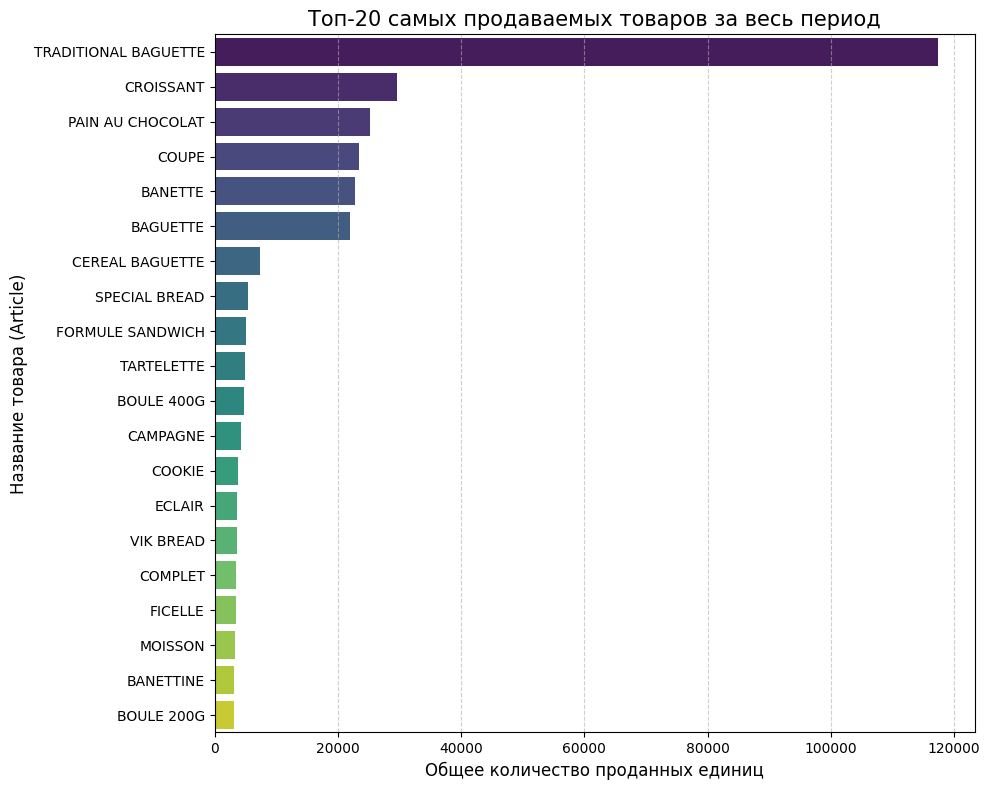

In [122]:
top_articles = df.groupby('article')['Quantity'].sum().sort_values(ascending=False).reset_index()

top_20 = top_articles.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_20, x='Quantity', y='article', palette='viridis')

plt.title('Топ-20 самых продаваемых товаров за весь период', fontsize=15)
plt.xlabel('Общее количество проданных единиц', fontsize=12)
plt.ylabel('Название товара (Article)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

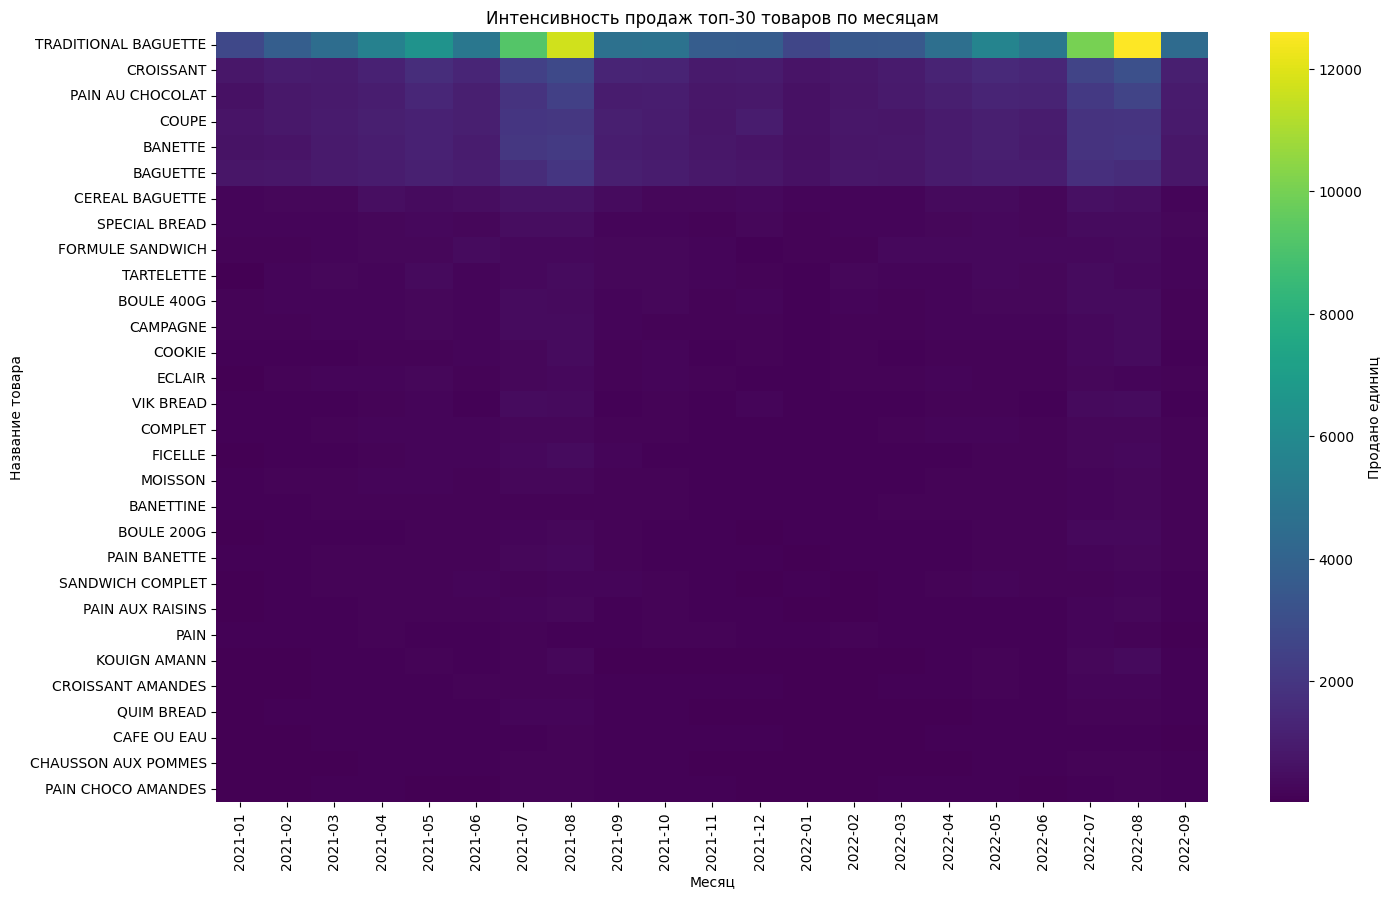

In [123]:
df['date'] = pd.to_datetime(df['date'])
df['month_year'] = df['date'].dt.to_period('M')

pivot_df = df.groupby(['article', 'month_year'])['Quantity'].sum().unstack()

pivot_df_filtered = pivot_df.loc[df.groupby('article')['Quantity'].sum().nlargest(30).index]
plt.figure(figsize=(16, 10))
sns.heatmap(pivot_df_filtered, cmap='viridis', annot=False, cbar_kws={'label': 'Продано единиц'})
plt.title('Интенсивность продаж топ-30 товаров по месяцам')
plt.ylabel('Название товара')
plt.xlabel('Месяц')
plt.show()

In [124]:
#создаем дополнительные колонки с описанием, сколько продалось до 15:00, после этого времени
before_15 = df[df['hour'] < 15].groupby(['date', 'article'])['Quantity'].sum().reset_index(name='qty_before_15')
daily_total = df.groupby(['date', 'article', 'unit_price'])['Quantity'].sum().reset_index(name='total_day_qty')
final_df = pd.merge(daily_total, before_15, on=['date', 'article'], how='left').fillna(0)

stock_initial = 1000

In [125]:
final_df.head()

,date,article,unit_price,total_day_qty,qty_before_15
0,2021-01-02,BAGUETTE,0.90,46.0,46.0
1,2021-01-02,BANETTE,1.05,40.0,40.0
2,2021-01-02,BANETTINE,0.60,6.0,6.0
3,2021-01-02,BOULE 200G,1.10,6.0,6.0
4,2021-01-02,BOULE 400G,1.50,11.0,11.0


In [126]:
import holidays

#колонки со значением день недели, месяц, выходной, сколько осталось на складе(витрине) после 15:00, создаем метку
final_df['day_of_week'] = pd.to_datetime(final_df['date']).dt.dayofweek
final_df['month'] = pd.to_datetime(final_df['date']).dt.month
fr_holidays = holidays.France()
final_df['is_holiday'] = final_df['date'].apply(lambda x: 1 if x in fr_holidays else 0)
final_df.head()
final_df['stock_remaining_after_15'] = (100 - final_df['qty_before_15']).clip(lower=0)
final_df['will_sell_out'] = (
    (final_df['total_day_qty'] - (final_df['qty_before_15'] * 1.1)) <= 0
).astype(int)

In [127]:
final_df['will_sell_out'].value_counts()

will_sell_out
1    20104
0    10155
Name: count, dtype: int64

In [128]:
import optuna
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

X = final_df.drop(['will_sell_out','date','total_day_qty'], axis=1)
y = final_df['will_sell_out']

In [129]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=101)

In [130]:
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score

cat_cols = ['article'] 

def objective(trial):
    param = {
        "iterations": trial.suggest_int("iterations", 100, 800),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "auto_class_weights": "Balanced",
        "verbose": False,
        "random_state": 42,
        "cat_features": cat_cols 
    }
    
    model = CatBoostClassifier(**param)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    return f1_score(y_test, preds)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

print("Best param:", study.best_params)

[I 2026-03-04 13:26:39,153] A new study created in memory with name: no-name-aa1b6f0a-82b5-4c80-afee-242c1be41206
[I 2026-03-04 13:26:43,757] Trial 0 finished with value: 0.8051983584131327 and parameters: {'iterations': 720, 'depth': 7, 'learning_rate': 0.012196789133046762, 'l2_leaf_reg': 9.54703396224315}. Best is trial 0 with value: 0.8051983584131327.
[I 2026-03-04 13:26:46,579] Trial 1 finished with value: 0.814512841418671 and parameters: {'iterations': 631, 'depth': 5, 'learning_rate': 0.15619015358731994, 'l2_leaf_reg': 6.233290487327334}. Best is trial 1 with value: 0.814512841418671.
[I 2026-03-04 13:26:49,491] Trial 2 finished with value: 0.8157394843962008 and parameters: {'iterations': 767, 'depth': 4, 'learning_rate': 0.1527518201757563, 'l2_leaf_reg': 6.849659366251267}. Best is trial 2 with value: 0.8157394843962008.
[I 2026-03-04 13:26:53,368] Trial 3 finished with value: 0.8142195587033506 and parameters: {'iterations': 636, 'depth': 7, 'learning_rate': 0.04497974326

Best param: {'iterations': 769, 'depth': 9, 'learning_rate': 0.08944360574942213, 'l2_leaf_reg': 2.997229619743504}


In [131]:
final_model = CatBoostClassifier(
    **study.best_params, 
    cat_features=['article'],      
    auto_class_weights='Balanced',
    verbose=False,
    random_state=101)
final_model.fit(X_train, y_train)

CatBoostClassifier(auto_class_weights='Balanced', cat_features=['article'], depth=9, iterations=769, l2_leaf_reg=2.997229619743504, learning_rate=0.08944360574942213, random_state=101, verbose=False)

              precision    recall  f1-score   support

           0       0.64      0.78      0.71      2106
           1       0.87      0.77      0.82      3946

    accuracy                           0.77      6052
   macro avg       0.76      0.77      0.76      6052
weighted avg       0.79      0.77      0.78      6052



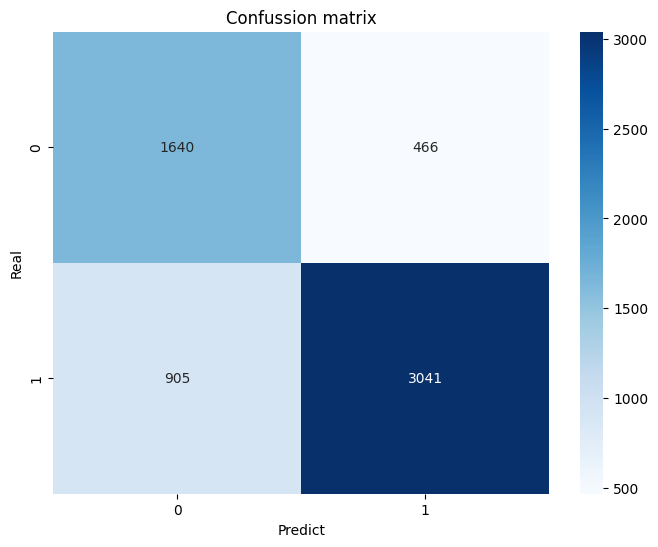

In [132]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
final_preds = final_model.predict(X_test)

print(classification_report(y_test, final_preds))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confussion matrix')
plt.ylabel('Real')
plt.xlabel('Predict')
plt.show()

<Axes: >

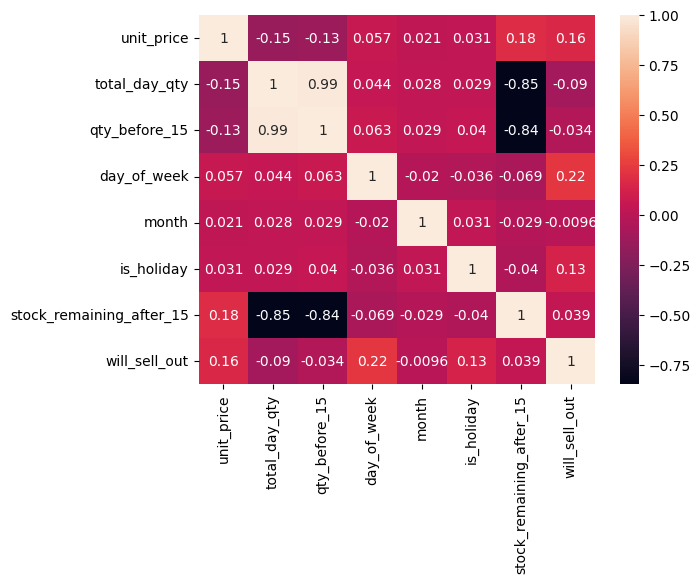

In [133]:
sns.heatmap(final_df.corr(numeric_only=True),annot=True)

In [134]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score, accuracy_score
import numpy as np
tscv = TimeSeriesSplit(n_splits=5)

cv_f1_scores = []
cv_accuracy_scores = []

for train_index, test_index in tscv.split(X):
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]
    
    model_cv = CatBoostClassifier(
        **study.best_params,
        cat_features=['article'],
        auto_class_weights='Balanced',
        verbose=False,
        random_state=42
    )
    
    model_cv.fit(X_train_cv, y_train_cv)
    preds_cv = model_cv.predict(X_test_cv)
    
    
    f1 = f1_score(y_test_cv, preds_cv)
    acc = accuracy_score(y_test_cv, preds_cv)
    
    cv_f1_scores.append(f1)
    cv_accuracy_scores.append(acc)
    
    print(f"F1: {f1:.3f}, Accuracy: {acc:.3f}")

print(f"Mean F1-Score: {np.mean(cv_f1_scores):.3f} (+/- {np.std(cv_f1_scores):.3f})")
print(f"Mean accuracy: {np.mean(cv_accuracy_scores):.3f} (+/- {np.std(cv_accuracy_scores):.3f})")

F1: 0.825, Accuracy: 0.758
F1: 0.775, Accuracy: 0.725
F1: 0.843, Accuracy: 0.795
F1: 0.816, Accuracy: 0.776
F1: 0.789, Accuracy: 0.746
Mean F1-Score: 0.810 (+/- 0.024)
Mean accuracy: 0.760 (+/- 0.024)
